In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("loanapproval.csv")

# Display first 5 rows
print(data.head())

# Display dataset information
print(data.info())

# Display missing values
print(data.isnull().sum())

   applicant_id  age  gender marital_status  annual_income  loan_amount  \
0             1   59    Male       Divorced         100073         7169   
1             2   49    Male        Married         112197        23556   
2             3   35    Male       Divorced          84429        27052   
3             4   63  Female         Single         124195        11313   
4             5   28  Female        Married          81627        13315   

   credit_score  num_dependents  existing_loans_count employment_status  \
0           793               1                     1        Unemployed   
1           789               0                     2          Employed   
2           372               1                     4        Unemployed   
3           808               3                     4     Self-employed   
4           689               0                     1        Unemployed   

   loan_approved  
0              1  
1              1  
2              0  
3              1  
4  

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns

# Convert categorical columns into numbers
label_encoder = LabelEncoder()

data['gender'] = label_encoder.fit_transform(data['gender'])
data['marital_status'] = label_encoder.fit_transform(data['marital_status'])
data['employment_status'] = label_encoder.fit_transform(data['employment_status'])

# Features and target
X = data.drop(['loan_approved', 'applicant_id'], axis=1)
y = data['loan_approved']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.84


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


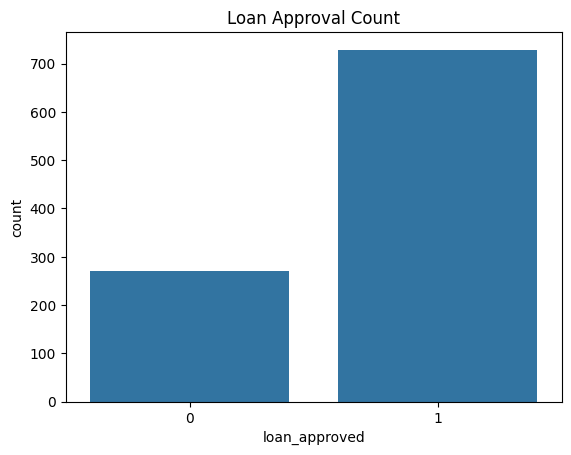

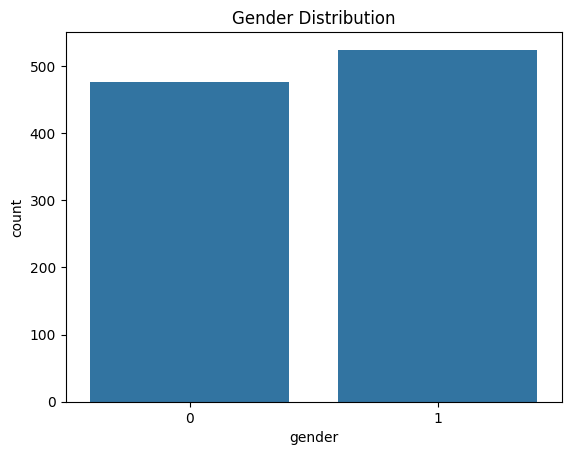

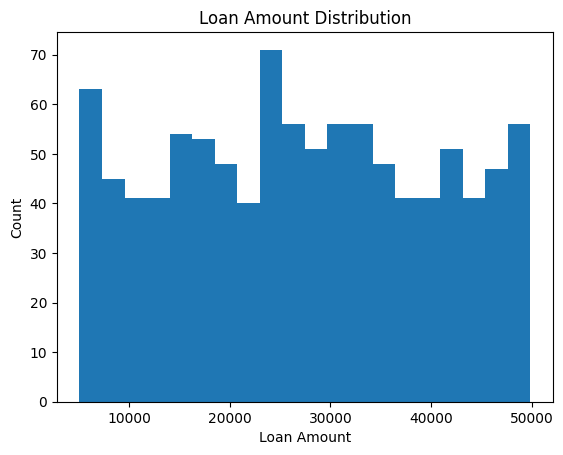

In [ ]:
# Visualization

# Loan Approval Count
sns.countplot(x='loan_approved', data=data)
plt.title("Loan Approval Count")
plt.show()

# Gender Distribution
sns.countplot(x='gender', data=data)
plt.title("Gender Distribution")
plt.show()

# Loan Amount Distribution
plt.hist(data['loan_amount'], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

In [ ]:
# Sample prediction

sample_data = [[1, 1, 75000, 15000, 780, 2, 1, 1,1]]

prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
